<a href="https://colab.research.google.com/github/Haricharanpampad/my-projects/blob/main/MNIST_Digit_Classification_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix


In [17]:
(X_train,Y_train),(X_test,Y_test)=mnist.load_data()

In [18]:
type(X_test)

numpy.ndarray

In [19]:
print(X_train.shape,Y_train.shape,X_test.shape,Y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [20]:
print(X_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

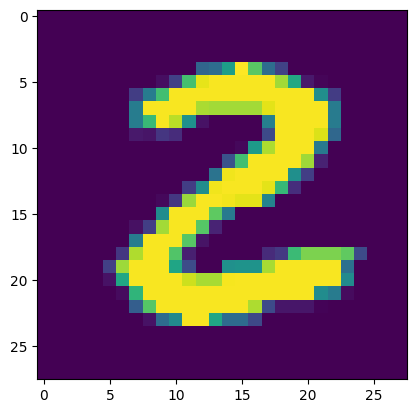

2


In [21]:
plt.imshow(X_train[25])
plt.show()

#and its labe
print(Y_train[25])

In [22]:
print(np.unique(Y_train))
print(np.unique(Y_test))


[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


In [23]:
#scaling the intesities from range 0-255 to 0-1
X_train=X_train/255
X_test=X_test/255


In [24]:
print(X_train[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

#Building Neural Networks (not cnn or rnn)

In [25]:
#layers setting
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28,)),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(10,activation='sigmoid') #no.of classes are only 10 classes so ten neurans

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
#compiling NN
model.compile(optimizer='adam', #like gradient descend used to find best fit parametes
              loss='sparse_categorical_crossentropy', # used while dealing with categoral classification [1-9],for 1 hot encoding we ll do with other class
              metrics=['accuracy'] )

In [29]:
model.fit(X_train,Y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9129 - loss: 0.2999
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9599 - loss: 0.1354
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9700 - loss: 0.0977
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9769 - loss: 0.0767
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9809 - loss: 0.0631
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9844 - loss: 0.0528
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9865 - loss: 0.0455
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9887 - loss: 0.0393
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9891 - loss: 0.0351
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9906 - loss: 0.0305


training data accuracy was 99%

accuracy of test data

In [30]:
loss,accuracy=model.evaluate(X_test,Y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9661 - loss: 0.1267


test accuracy is 96% so model not overfitted

In [32]:
X_test.shape

(10000, 28, 28)

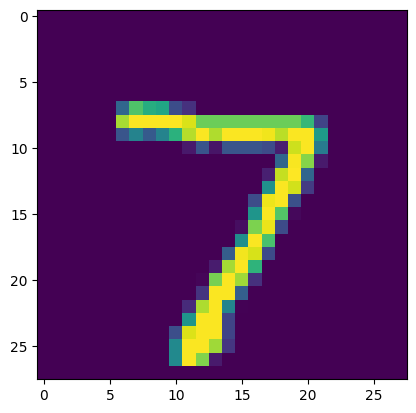

In [33]:
plt.imshow(X_test[0])
plt.show()

In [34]:
print(Y_test[0])

7


In [35]:
Y_pred=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [36]:
Y_pred.shape

(10000, 10)

In [37]:
print(Y_pred[0]) #probabilities that the data belong to class(0-9)

[5.4755933e-03 2.0657503e-04 2.6522237e-01 9.9658883e-01 1.1676053e-07
 2.4866117e-02 2.0508419e-15 9.9999988e-01 1.7312264e-04 9.1956383e-01]


In [38]:
#coverting probabilities into exact class which it belongs
label_for_first_image=np.argmax(Y_pred[0])
print(label_for_first_image)

7


In [39]:
#coverting prediction probability to class labels for all data points
Y_pred_labels=[np.argmax(i)for i in Y_pred]
print(Y_pred_labels)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(3), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

In [40]:
print(Y_pred) #before coverting to class

[[5.4755933e-03 2.0657503e-04 2.6522237e-01 ... 9.9999988e-01
  1.7312264e-04 9.1956383e-01]
 [5.3508316e-05 2.3337330e-01 9.9999559e-01 ... 6.5586547e-10
  8.3616208e-03 5.0243537e-10]
 [3.8037822e-03 9.9887449e-01 1.4154011e-02 ... 3.6144969e-01
  5.4253150e-02 1.4144428e-04]
 ...
 [1.1958405e-09 1.7768101e-06 3.6072437e-11 ... 2.0014925e-01
  6.1985370e-02 9.1779596e-01]
 [1.0007440e-06 9.0519097e-06 2.7957531e-10 ... 2.2841002e-06
  9.9767721e-01 1.9911151e-06]
 [5.7192738e-06 4.5312286e-06 3.9358859e-08 ... 6.1843718e-11
  3.5556706e-04 3.8477996e-08]]


Confusion matrix

In [41]:
conf_mat=confusion_matrix(Y_test,Y_pred_labels)


In [42]:
print(conf_mat)

tf.Tensor(
[[ 947    0    1    3    8    2    3    1    3   12]
 [   1 1121    0    6    0    1    2    0    4    0]
 [   9    4  957   28    6    0    3   15    7    3]
 [   0    0    3  995    1    2    0    5    1    3]
 [   0    1    3    0  960    0    6    3    1    8]
 [   3    0    0   29    2  841    7    1    4    5]
 [   1    3    1    0    8    2  941    0    2    0]
 [   0    3    3   13    1    1    0  993    1   13]
 [   3    2    2   21    4    4    6    2  924    6]
 [   0    3    1    9    7    0    1    3    3  982]], shape=(10, 10), dtype=int32)


Text(158.22222222222223, 0.5, 'PREDICTED LABELs')

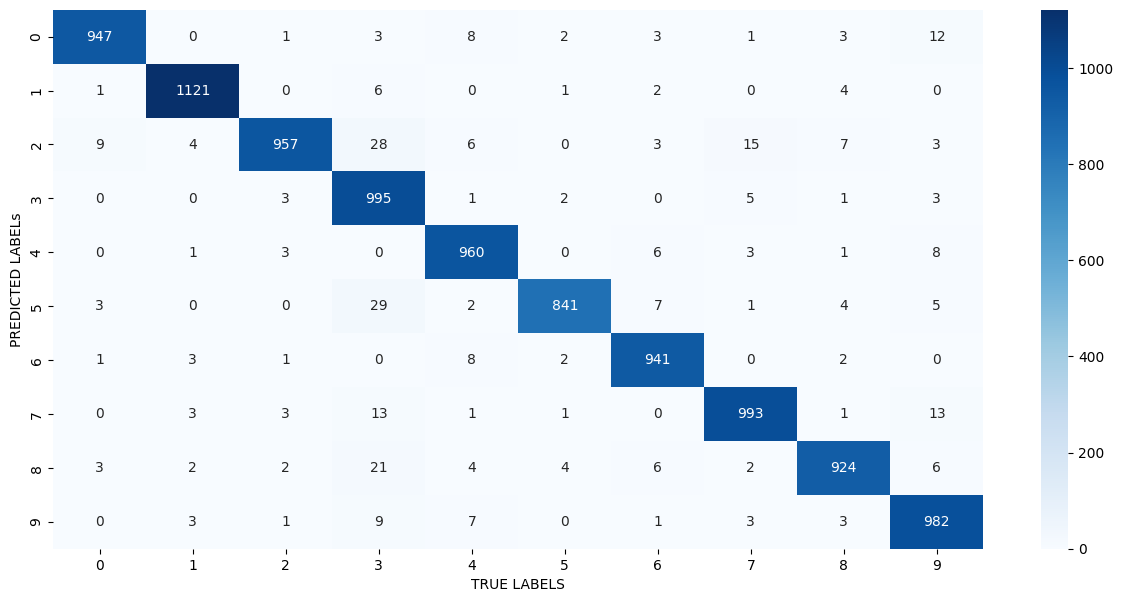

In [43]:
plt.figure(figsize=(15,7))
sns.heatmap(conf_mat,annot=True,fmt='d',cmap='Blues')
plt.xlabel('TRUE LABELS')
plt.ylabel('PREDICTED LABELs')

#building a predictive system

In [44]:
input_image_path='/content/MNIST_digit.png'
input_image=cv2.imread(input_image_path)
type(input_image)

numpy.ndarray

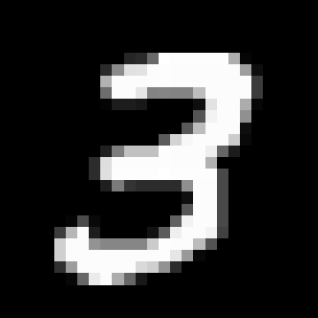

In [45]:
cv2_imshow(input_image)

In [46]:
input_image.shape

(318, 318, 3)

In [47]:
# converting to gray scale
grayscale=cv2.cvtColor(input_image,cv2.COLOR_RGB2GRAY)

In [48]:
grayscale.shape

(318, 318)

In [49]:
ip_resize=cv2.resize(grayscale,(28,28))

In [50]:
ip_resize.shape

(28, 28)

In [52]:
cv2_imshow(ip_resize)

In [53]:
ip_resize=ip_resize/255

In [54]:
type(ip_resize)

numpy.ndarray

In [56]:
image_reshaped=np.reshape(ip_resize,[1,28,28]) #input is only a one image of dimension 28,28

In [57]:
ip_pred=model.predict(image_reshaped)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [58]:
print(ip_pred)

[[2.5746592e-11 4.4153364e-08 3.3794159e-08 1.0000000e+00 8.9465154e-13
  2.4354104e-03 2.6933034e-22 6.2963307e-02 5.1407716e-03 9.9050730e-01]]


In [59]:
ip_pred_label=np.argmax(ip_pred)

In [60]:
print(ip_pred_label)

3


#predicate system

path of image to be predicted/content/MNIST_digit.png


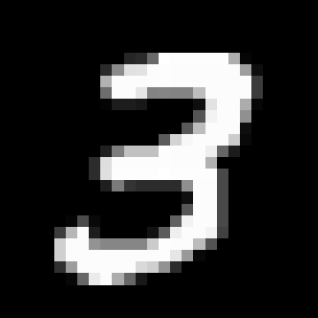

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
handwritten image is  3


In [61]:
input_image_path=input('path of image to be predicted')
input_image=cv2.imread(input_image_path)
cv2_imshow(input_image)
grayscale=cv2.cvtColor(input_image,cv2.COLOR_RGB2GRAY)
ip_resize=cv2.resize(grayscale,(28,28))
ip_resize=ip_resize/255
image_reshaped=np.reshape(ip_resize,[1,28,28])
ip_pred=model.predict(image_reshaped)
ip_pred_label=np.argmax(ip_pred)
print('handwritten image is ',ip_pred_label)